<a href="https://colab.research.google.com/github/Tanish-ops7710/DAFA1/blob/main/FA2Q5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset loaded successfully!
Shape: (1470, 35)

Columns:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Missing Values:
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EnvironmentSatisfaction     0
Gender                      0
HourlyR

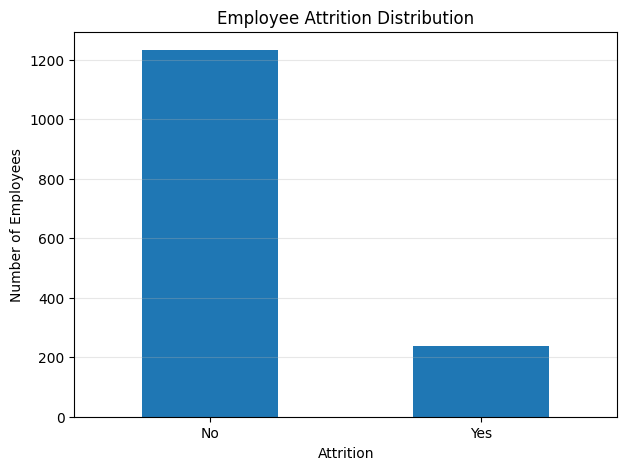

In [2]:
# ==========================================
# Q5 - STEP 1
# LOAD + CLEAN + DESCRIPTIVE STATISTICS
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('/content/archive.zip')

print("Dataset loaded successfully!")
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

# ------------------------------------------
# Basic cleaning
# ------------------------------------------

# Remove unnecessary employee ID if present
df = df.drop(
    columns=['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'],
    errors='ignore'
)

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# ------------------------------------------
# ATTRITION DISTRIBUTION
# ------------------------------------------

print("\n" + "="*60)
print("ATTRITION DISTRIBUTION")
print("="*60)

print(df['Attrition'].value_counts())

print("\nAttrition Percentage:")
print(
    df['Attrition']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

# ------------------------------------------
# DESCRIPTIVE STATISTICS
# ------------------------------------------

print("\n" + "="*60)
print("DESCRIPTIVE STATISTICS")
print("="*60)

print(
    df[
        ['Age', 'MonthlyIncome', 'JobSatisfaction',
         'YearsAtCompany', 'YearsInCurrentRole']
    ].describe()
)

# ------------------------------------------
# ATTRITION BY DEPARTMENT
# ------------------------------------------

print("\n" + "="*60)
print("ATTRITION BY DEPARTMENT")
print("="*60)

department_attrition = pd.crosstab(
    df['Department'],
    df['Attrition'],
    normalize='index'
) * 100

print(department_attrition.round(2))

# ------------------------------------------
# ATTRITION BY JOB ROLE
# ------------------------------------------

print("\n" + "="*60)
print("ATTRITION BY JOB ROLE")
print("="*60)

role_attrition = pd.crosstab(
    df['JobRole'],
    df['Attrition'],
    normalize='index'
) * 100

print(role_attrition.round(2))

# ------------------------------------------
# VISUALIZATION
# ------------------------------------------

plt.figure(figsize=(7,5))

df['Attrition'].value_counts().plot(
    kind='bar'
)

plt.title('Employee Attrition Distribution')
plt.xlabel('Attrition')
plt.ylabel('Number of Employees')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.show()

In [3]:
# ==========================================
# Q5 - STEP 2
# INFERENTIAL STATISTICS
# ==========================================

from scipy.stats import chi2_contingency, ttest_ind

# ------------------------------------------
# CHI-SQUARE TESTS
# ------------------------------------------

categorical_vars = [
    'JobRole',
    'OverTime',
    'JobSatisfaction'
]

print("="*65)
print("CHI-SQUARE TESTS")
print("="*65)

for variable in categorical_vars:

    table = pd.crosstab(
        df[variable],
        df['Attrition']
    )

    chi2, p, dof, expected = chi2_contingency(table)

    print("\n", variable)
    print("-"*50)
    print("Chi-Square:", round(chi2, 4))
    print("P-Value:", p)

    if p < 0.05:
        print("Result: Significant relationship with Attrition")
    else:
        print("Result: Not significant")

# ------------------------------------------
# T-TEST: MONTHLY INCOME
# ------------------------------------------

attrition_yes = df[
    df['Attrition'] == 'Yes'
]['MonthlyIncome']

attrition_no = df[
    df['Attrition'] == 'No'
]['MonthlyIncome']

t_stat, p_value = ttest_ind(
    attrition_yes,
    attrition_no,
    equal_var=False
)

print("\n" + "="*65)
print("T-TEST: MONTHLY INCOME")
print("="*65)

print("Attrition Yes Mean:",
      round(attrition_yes.mean(), 2))

print("Attrition No Mean:",
      round(attrition_no.mean(), 2))

print("T-Statistic:",
      round(t_stat, 4))

print("P-Value:",
      p_value)

if p_value < 0.05:
    print("Result: MonthlyIncome is significantly different.")
else:
    print("Result: No significant difference.")

CHI-SQUARE TESTS

 JobRole
--------------------------------------------------
Chi-Square: 86.1903
P-Value: 2.752481638050657e-15
Result: Significant relationship with Attrition

 OverTime
--------------------------------------------------
Chi-Square: 87.5643
P-Value: 8.15842372153832e-21
Result: Significant relationship with Attrition

 JobSatisfaction
--------------------------------------------------
Chi-Square: 17.5051
P-Value: 0.0005563004510387556
Result: Significant relationship with Attrition

T-TEST: MONTHLY INCOME
Attrition Yes Mean: 4787.09
Attrition No Mean: 6832.74
T-Statistic: -7.4826
P-Value: 4.433588628286071e-13
Result: MonthlyIncome is significantly different.


K-MEANS CLUSTER DISTRIBUTION
Cluster
0    357
1    862
2    251
Name: count, dtype: int64

CLUSTER SUMMARY
         Employees  AvgAge  AvgIncome  AvgJobSatisfaction  AvgYearsAtCompany
Cluster                                                                     
0              357   35.44    5038.88                2.78               5.41
1              862   34.48    4690.01                2.71               5.51
2              251   47.43   14811.31                2.71              14.43

ATTRITION RATE BY CLUSTER (%)
Cluster
0    33.61
1    11.37
2     7.57
Name: Attrition_Binary, dtype: float64


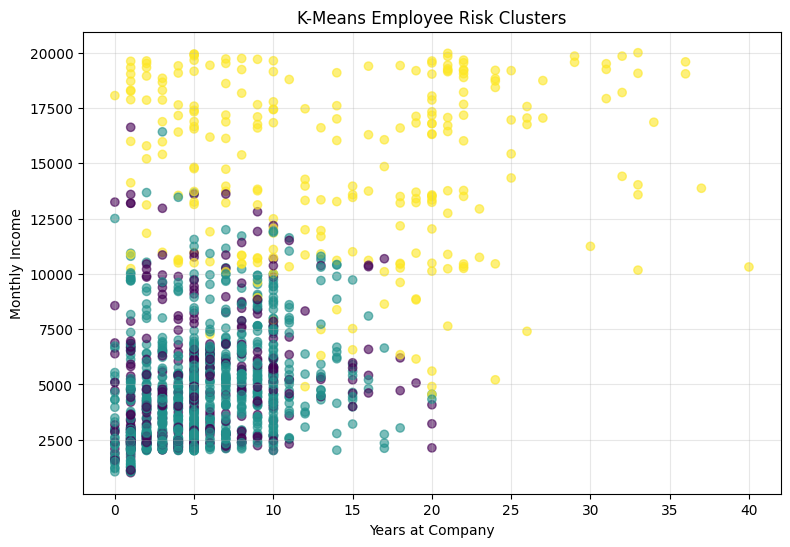

In [4]:
# ==========================================
# Q5 - STEP 3
# K-MEANS + EMPLOYEE RISK SEGMENTATION
# ==========================================

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Convert relevant categorical variables
cluster_df = pd.DataFrame()

cluster_df['OverTime'] = df['OverTime'].map({
    'Yes': 1,
    'No': 0
})

cluster_df['JobSatisfaction'] = df['JobSatisfaction']

cluster_df['YearsAtCompany'] = df['YearsAtCompany']

cluster_df['MonthlyIncome'] = df['MonthlyIncome']

cluster_df['Age'] = df['Age']

# Add WorkLifeBalance if available
if 'WorkLifeBalance' in df.columns:
    cluster_df['WorkLifeBalance'] = df['WorkLifeBalance']

cluster_df = cluster_df.fillna(
    cluster_df.median()
)

# ------------------------------------------
# Standardize
# ------------------------------------------

scaler = StandardScaler()

X_cluster = scaler.fit_transform(cluster_df)

# ------------------------------------------
# K-Means
# ------------------------------------------

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X_cluster)

print("="*60)
print("K-MEANS CLUSTER DISTRIBUTION")
print("="*60)

print(df['Cluster'].value_counts().sort_index())

# ------------------------------------------
# Cluster summary
# ------------------------------------------

cluster_summary = df.groupby('Cluster').agg(
    Employees=('Cluster', 'size'),
    AvgAge=('Age', 'mean'),
    AvgIncome=('MonthlyIncome', 'mean'),
    AvgJobSatisfaction=('JobSatisfaction', 'mean'),
    AvgYearsAtCompany=('YearsAtCompany', 'mean')
).round(2)

print("\nCLUSTER SUMMARY")
print("="*60)
print(cluster_summary)

# ------------------------------------------
# Attrition rate by cluster
# ------------------------------------------

df['Attrition_Binary'] = (
    df['Attrition'] == 'Yes'
).astype(int)

cluster_risk = (
    df.groupby('Cluster')['Attrition_Binary']
    .mean()
    .mul(100)
    .round(2)
)

print("\nATTRITION RATE BY CLUSTER (%)")
print("="*60)
print(cluster_risk)

# ------------------------------------------
# Visualization
# ------------------------------------------

plt.figure(figsize=(9,6))

plt.scatter(
    df['YearsAtCompany'],
    df['MonthlyIncome'],
    c=df['Cluster'],
    alpha=0.6
)

plt.xlabel('Years at Company')
plt.ylabel('Monthly Income')
plt.title('K-Means Employee Risk Clusters')
plt.grid(alpha=0.3)

plt.show()

In [5]:
# ==========================================
# Q5 - STEP 4
# TOP 3 FACTORS + RETENTION STRATEGIES
# ==========================================

print("="*65)
print("TOP FACTORS CONTRIBUTING TO ATTRITION")
print("="*65)

# Compare attrition rates for important categorical variables

factor_results = {}

# OverTime
factor_results['OverTime'] = (
    df.groupby('OverTime')['Attrition_Binary']
    .mean()
    .max()
)

# JobSatisfaction
factor_results['JobSatisfaction'] = (
    df.groupby('JobSatisfaction')['Attrition_Binary']
    .mean()
    .max()
)

# JobRole
factor_results['JobRole'] = (
    df.groupby('JobRole')['Attrition_Binary']
    .mean()
    .max()
)

# YearsAtCompany
df['TenureGroup'] = pd.cut(
    df['YearsAtCompany'],
    bins=[-1, 2, 5, 10, 100],
    labels=[
        '0-2 Years',
        '3-5 Years',
        '6-10 Years',
        '10+ Years'
    ]
)

factor_results['Tenure'] = (
    df.groupby(
        'TenureGroup',
        observed=True
    )['Attrition_Binary']
    .mean()
    .max()
)

factor_table = (
    pd.Series(factor_results)
    .sort_values(ascending=False)
)

print("\nFactor ranking:")
print(
    (factor_table * 100).round(2)
)

print("\n" + "="*65)
print("TOP 3 ATTRITION FACTORS")
print("="*65)

for i, (factor, value) in enumerate(
    factor_table.head(3).items(),
    start=1
):
    print(
        f"{i}. {factor}: "
        f"{value*100:.2f}% maximum group attrition rate"
    )

# ------------------------------------------
# HIGH-RISK CLUSTER
# ------------------------------------------

highest_risk_cluster = cluster_risk.idxmax()

print("\n" + "="*65)
print("HIGH-RISK EMPLOYEE CLUSTER")
print("="*65)

print(
    "Cluster", highest_risk_cluster,
    "has the highest attrition rate of",
    cluster_risk[highest_risk_cluster],
    "%"
)

# ------------------------------------------
# RETENTION RECOMMENDATIONS
# ------------------------------------------

print("\n" + "="*65)
print("RETENTION STRATEGIES")
print("="*65)

print("""
1. Overtime Management:
   Reduce excessive overtime and provide better workload
   distribution for employees frequently working overtime.

2. Job Satisfaction:
   Conduct employee feedback surveys and improve
   recognition, career growth and workplace conditions.

3. High-Risk Employee Alerts:
   Monitor employees belonging to the high-risk cluster
   and provide targeted retention interventions.

4. Tenure-Based Retention:
   Provide career-development opportunities and incentives
   particularly for employees in early and mid-career stages.
""")

TOP FACTORS CONTRIBUTING TO ATTRITION

Factor ranking:
JobRole            39.76
OverTime           30.53
Tenure             29.82
JobSatisfaction    22.84
dtype: float64

TOP 3 ATTRITION FACTORS
1. JobRole: 39.76% maximum group attrition rate
2. OverTime: 30.53% maximum group attrition rate
3. Tenure: 29.82% maximum group attrition rate

HIGH-RISK EMPLOYEE CLUSTER
Cluster 0 has the highest attrition rate of 33.61 %

RETENTION STRATEGIES

1. Overtime Management:
   Reduce excessive overtime and provide better workload
   distribution for employees frequently working overtime.

2. Job Satisfaction:
   Conduct employee feedback surveys and improve
   recognition, career growth and workplace conditions.

3. High-Risk Employee Alerts:
   Monitor employees belonging to the high-risk cluster
   and provide targeted retention interventions.

4. Tenure-Based Retention:
   Provide career-development opportunities and incentives
   particularly for employees in early and mid-career stages.

